In [3]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
df = pd.read_csv(r"C:\Users\nirma\Downloads\tested (1).csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [5]:
df['Age']=df['Age'].fillna(df['Age'].median())
df.drop('Name',axis=1,inplace=True)
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [6]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

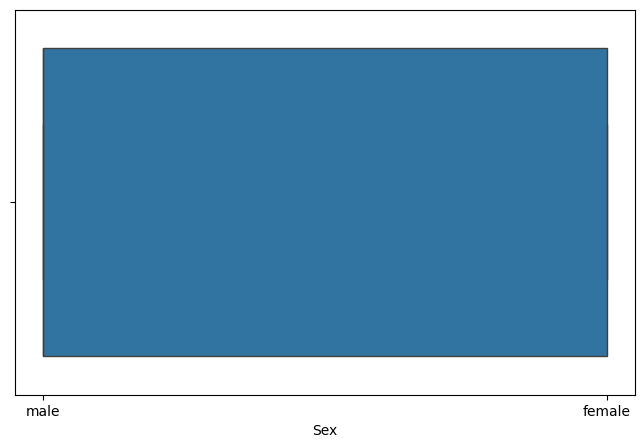

In [7]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Sex'])
plt.show()

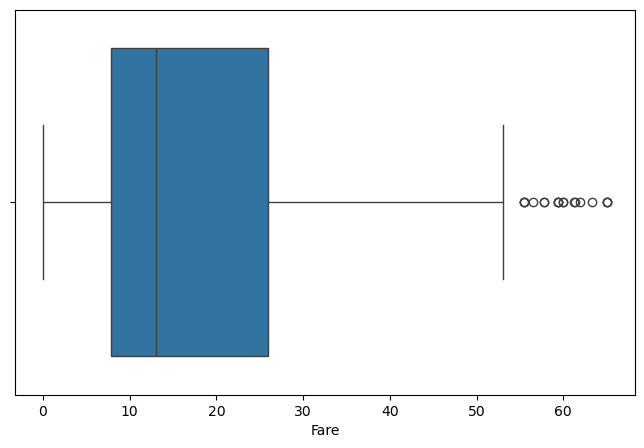

In [8]:
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR =Q3 - Q1
lower_limit = Q1 - 1.5*IQR
upper_limit =Q3 +1.5*IQR
df =df[(df['Fare'] >=lower_limit)&(df['Fare'] <=upper_limit)]
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Fare'])
plt.show()

In [9]:
df.select_dtypes(include='object').columns


Index(['Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')

In [ ]:
df=pd.get_dummies(df,columns=['Embarked'],drop_first=True)

In [ ]:
from sklearn.pre[processing import LabelEncoder
le=LabelEncoder()
df['Sex']= le.fit_transforms(df['Sex'])

In [10]:
df['FamilySize'] = df['SibSp'] +df['Parch']
df['IsAlone'] = np.where(df['FamilySize']>0, 0,1)
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,IsAlone
0,892,0,3,male,34.5,0,0,330911,7.8292,NaN,Q,0,1
1,893,1,3,female,47.0,1,0,363272,7.0000,NaN,S,1,0
2,894,0,2,male,62.0,0,0,240276,9.6875,NaN,Q,0,1
3,895,0,3,male,27.0,0,0,315154,8.6625,NaN,S,0,1
4,896,1,3,female,22.0,1,1,3101298,12.2875,NaN,S,2,0


In [11]:
df.columns



Index(['PassengerId', 'Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked', 'FamilySize', 'IsAlone'],
      dtype='object')